In [1]:
import os
import sys

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from PIL import Image
import seaborn as sns

# import own modules
_repo_name = "ofdma-spectrum-anomalies-simulation"
_module_path = os.getcwd()[: os.getcwd().find(_repo_name) + len(_repo_name)]
sys.path.append(os.path.join(os.path.abspath(_module_path), "src"))

from utils.data_utils import get_datapath

# some parameters and configuration for figures
COL_WIDTH = 3.5 # in inches
TWO_COL_WIDTH = 7.16 # in inches
RATIO = 1.618 # golden ratio
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 8

figure_path = os.path.join("..", "figures")

In [2]:
DATASET_NR = 0

datapath = get_datapath(_repo_name)
datapath = os.path.join(datapath, str(DATASET_NR))

In [3]:
def get_filename(sample_idx):
    return os.path.join(datapath, "images", f"alloc_res-{str(sample_idx).zfill(5)}.png")

In [4]:
# Get matplotlib default color cycle for later use
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

Figure saved to ..\figures\resource_allocation_sample_12000.pdf


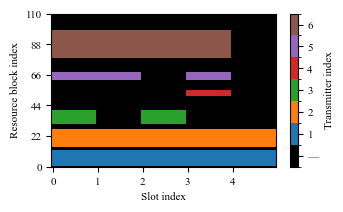

In [5]:
# Configuration
save_fig = True
with_labels = True

sample_idx = 12000 # Set custom sample index here

# 5G resource grid parameters
SUBCARRIERS_PER_RB = 12
SYMBOLS_PER_SLOT = 14

# Load image
img = Image.open(get_filename(sample_idx))
img = np.array(img)  # Already uint8, values 0-10, no denormalization needed

# Determine number of users (maximum value in array)
max_user_id = int(np.max(img))

# Create discrete colormap and normalization based on actual number of users
cmap_colors = ['black'] + colors[:max_user_id]
discrete_cmap = mcolors.ListedColormap(cmap_colors)
norm = mcolors.BoundaryNorm(boundaries=np.arange(-0.5, max_user_id + 1.5, 1), ncolors=max_user_id + 1)

# Create figure
fig, ax = plt.subplots(figsize=(COL_WIDTH, COL_WIDTH/RATIO))

# Plot with discrete colormap
im = ax.imshow(img, aspect="auto", origin="lower", cmap=discrete_cmap, norm=norm, interpolation="none")

if with_labels:
    # Set axis labels for 5G resource grid
    plt.xlabel("Slot index")
    plt.ylabel("Resource block index")

    # Set ticks for 5G resource grid
    n_symbols = img.shape[1]
    n_subcarriers = img.shape[0]

    # X-axis: one tick per slot
    slot_ticks = np.arange(0, n_symbols, SYMBOLS_PER_SLOT)
    slot_labels = np.arange(len(slot_ticks))
    ax.set_xticks(slot_ticks)
    ax.set_xticklabels(slot_labels)

    # Y-axis: 6 evenly spaced ticks (in pixel coordinates), with RB labels
    n_rb_ticks = 6
    rb_tick_pixels = np.linspace(0, n_subcarriers - 1, n_rb_ticks)
    rb_tick_labels = np.round(rb_tick_pixels / SUBCARRIERS_PER_RB).astype(int)
    ax.set_yticks(rb_tick_pixels)
    ax.set_yticklabels(rb_tick_labels)

    # Create colorbar with discrete labels based on actual users present
    cbar_ticks = np.arange(0, max_user_id + 1)
    cbar = plt.colorbar(im, ax=ax, ticks=cbar_ticks, boundaries=np.arange(-0.5, max_user_id + 1.5, 1))

    # Create labels: 0 = em-dash, 1-N = transmitter IDs
    cbar_labels = ["—"] + [str(i) for i in range(1, max_user_id + 1)]
    cbar.ax.set_yticklabels(cbar_labels)
    cbar.set_label("Transmitter index")
else:
    ax.axis("off")

plt.tight_layout()

# Save figure if requested
if save_fig:
    filename = f"resource_allocation_sample_{sample_idx}.pdf"

    os.makedirs(figure_path, exist_ok=True)
    plt.savefig(os.path.join(figure_path, filename), dpi=300, bbox_inches="tight")
    print(f"Figure saved to {os.path.join(figure_path, filename)}")

plt.show()